Generated Numbers:
[8443, 2842, 769, 5913, 9635, 8332, 4222, 8252, 955, 9120]

K-S Table
i	Ri		i/n		(i-1)/n		D+		D-
1 	 0.0769 	 0.1 	 0.0 		 0.0231 	 0.0769
2 	 0.0955 	 0.2 	 0.1 		 0.1045 	 -0.0045
3 	 0.2842 	 0.3 	 0.2 		 0.0158 	 0.0842
4 	 0.4222 	 0.4 	 0.3 		 -0.0222 	 0.1222
5 	 0.5913 	 0.5 	 0.4 		 -0.0913 	 0.1913
6 	 0.8252 	 0.6 	 0.5 		 -0.2252 	 0.3252
7 	 0.8332 	 0.7 	 0.6 		 -0.1332 	 0.2332
8 	 0.8443 	 0.8 	 0.7 		 -0.0443 	 0.1443
9 	 0.912 	 0.9 	 0.8 		 -0.012 	 0.112
10 	 0.9635 	 1.0 	 0.9 		 0.0365 	 0.0635

D = 0.3252
Critical Value = 0.4301
Accept H0 (Uniform Distribution)


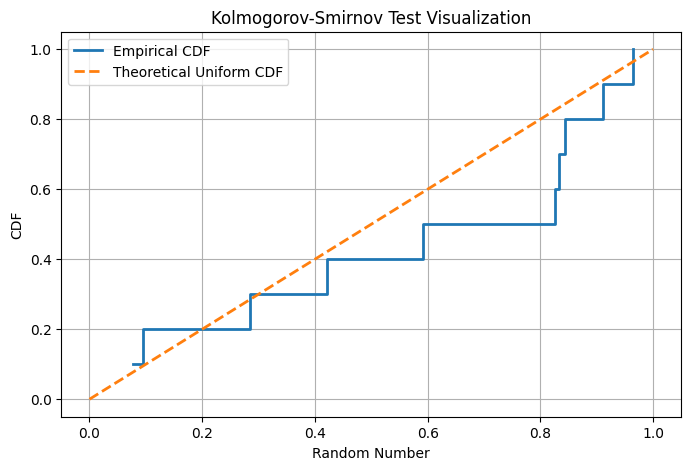

In [6]:
# Question:
# You are tasked with generating pseudo-random numbers using the Mid-Square Method
# and using those numbers to perform the Kolmogorov-Smirnov (K-S) test for uniformity.
# Start with a 4-digit seed (e.g., 5731).

import math

# Mid-Square Method
seed = 5731
n = 10
random_numbers = []

for i in range(n):
    square = str(seed * seed).zfill(8)   # make it 8 digits
    seed = int(square[2:6])              # take middle 4 digits
    random_numbers.append(seed)

print("Generated Numbers:")
print(random_numbers)

# Convert into Uniform(0,1)
u = []
for x in random_numbers:
    u.append(x / 10000)

u.sort()

# K-S Test
D_plus = []
D_minus = []

print("\nK-S Table")
print("i\tRi\t\ti/n\t\t(i-1)/n\t\tD+\t\tD-")

for i in range(len(u)):
    dp = (i + 1) / n - u[i]
    dm = u[i] - i / n

    D_plus.append(dp)
    D_minus.append(dm)

    print(i + 1, "\t",
          round(u[i],4), "\t",
          round((i+1)/n,4), "\t",
          round(i/n,4), "\t\t",
          round(dp,4), "\t",
          round(dm,4))

D = max(max(D_plus), max(D_minus))
D_critical = 1.36 / math.sqrt(n)

print("\nD =", round(D,4))
print("Critical Value =", round(D_critical,4))

if D < D_critical:
    print("Accept H0 (Uniform Distribution)")
else:
    print("Reject H0 (Not Uniform Distribution)")





# ======================
# Visualization
# ======================

# Empirical CDF values
empirical_cdf = []
for i in range(n):
    empirical_cdf.append((i + 1) / n)

plt.figure(figsize=(8,5))

# Empirical distribution
plt.step(
    u,
    empirical_cdf,
    where='post',
    label='Empirical CDF',
    linewidth=2
)

# Theoretical uniform distribution
plt.plot(
    [0, 1],
    [0, 1],
    '--',
    label='Theoretical Uniform CDF',
    linewidth=2
)

plt.title("Kolmogorov-Smirnov Test Visualization")
plt.xlabel("Random Number")
plt.ylabel("CDF")
plt.grid(True)
plt.legend()

plt.show()